### Stock Market Prediction using Stacked LSTM

In [4]:
## Using keras and Tensorflow for the model

Tiingo is a financial data platform that provides a wide range of services, primarily focused on delivering accurate, up-to-date financial and market data for investors, traders, and developers. It's particularly popular for its API, which allows users to programmatically access financial data such as historical stock prices, real-time market data, news, and more.

In [5]:
## Data Collection
import pandas as pd
import pandas_datareader as pdr
import numpy as np


In [6]:
import os
from dotenv import load_dotenv  #ye sab kuch load kr deta hai .env mein se

load_dotenv()

TINGO_API_KEY=os.getenv("TINGO_API_KEY")

In [7]:
# df = pdr.get_data_tiingo('AAPL', api_key=TINGO_API_KEY)

In [8]:
import requests
import pandas as pd

# Tiingo API endpoint for daily data with date range
url = "https://api.tiingo.com/tiingo/daily/AAPL/prices"

# Your Tiingo API key
api_key = '534f2a0bbba9dbeb5e2f927657b30e9f33d45b91'

# Set your desired date range (for example, past 30 days)
params = {
    'startDate': '2015-12-01',  # Set the start date
    'endDate': '2022-12-31',    # Set the end date
}

# Headers for authentication
headers = {
    'Authorization': f'Token {api_key}'
}

# Make the request to Tiingo API
response = requests.get(url, headers=headers, params=params)

# Check if the request was successful
if response.status_code == 200:
    # Convert the response data to JSON format
    data = response.json()

    # Convert the data to a Pandas DataFrame
    df = pd.DataFrame(data)

    # Display the first few rows of the DataFrame
    print(df.head())
else:
    print(f"Error: {response.status_code}")


                       date   close    high     low    open    volume  \
0  2015-12-01T00:00:00.000Z  117.34  118.81  116.86  118.75  34852374   
1  2015-12-02T00:00:00.000Z  116.28  118.11  116.08  117.05  33386563   
2  2015-12-03T00:00:00.000Z  115.20  116.79  114.22  116.55  41569509   
3  2015-12-04T00:00:00.000Z  119.03  119.25  115.11  115.29  57776977   
4  2015-12-07T00:00:00.000Z  118.28  119.86  117.81  118.98  32084249   

    adjClose    adjHigh     adjLow    adjOpen  adjVolume  divCash  splitFactor  
0  26.573652  26.906559  26.464948  26.892971  139409496      0.0          1.0  
1  26.333597  26.748032  26.288304  26.507977  133546252      0.0          1.0  
2  26.089013  26.449095  25.867075  26.394743  166278036      0.0          1.0  
3  26.956382  27.006204  26.068631  26.109395  231107908      0.0          1.0  
4  26.786531  27.144349  26.680092  26.945058  128336996      0.0          1.0  


In [9]:
df.to_csv('AAPL.csv')

In [10]:
df=pd.read_csv('AAPL.csv')

In [11]:
print(df.shape)


(1784, 14)


In [12]:
df.head(5)  # Return first n rows of dataframe (default is 5).

# df.head without parentheses is a reference to the head method itself, not the output of it.

,Unnamed: 0,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,0,2015-12-01T00:00:00.000Z,117.34,118.81,116.86,118.75,34852374,26.573652,26.906559,26.464948,26.892971,139409496,0.0,1.0
1,1,2015-12-02T00:00:00.000Z,116.28,118.11,116.08,117.05,33386563,26.333597,26.748032,26.288304,26.507977,133546252,0.0,1.0
2,2,2015-12-03T00:00:00.000Z,115.20,116.79,114.22,116.55,41569509,26.089013,26.449095,25.867075,26.394743,166278036,0.0,1.0
3,3,2015-12-04T00:00:00.000Z,119.03,119.25,115.11,115.29,57776977,26.956382,27.006204,26.068631,26.109395,231107908,0.0,1.0
4,4,2015-12-07T00:00:00.000Z,118.28,119.86,117.81,118.98,32084249,26.786531,27.144349,26.680092,26.945058,128336996,0.0,1.0


In [13]:
df1=df.reset_index()['close']

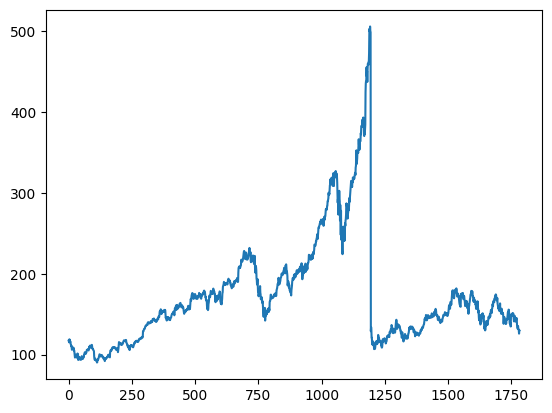

In [14]:
import matplotlib.pyplot as plt
plt.plot(df1)

In [15]:
from sklearn.preprocessing import MinMaxScaler
scalar=MinMaxScaler(feature_range=(0,1))
df1=scalar.fit_transform(np.array(df1).reshape(-1,1))

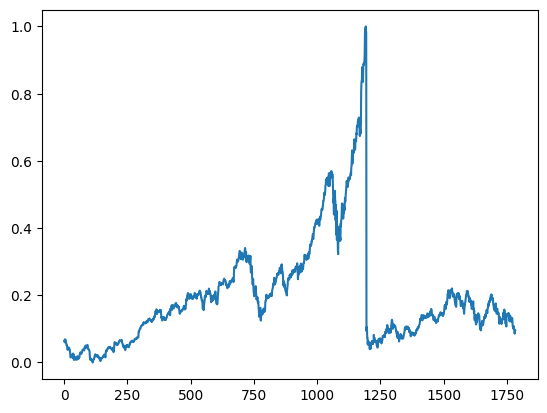

In [16]:
plt.plot(df1)

In [17]:
## splitting dataset into train and test split  
# Preprocessing the data
training_size=int(len(df1)*0.65)
test_size=len(df1)-training_size
train_data,test_data=df1[0:training_size,:],df1[training_size:len(df1),:1]

In [18]:
training_size,test_size

(1159, 625)

In [19]:
import numpy
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-time_step-1):
        a = dataset[i:(i+time_step), 0]   ###i=0, X_train=0,1,2,3-----99  Y_train= 100 
        dataX.append(a)
        dataY.append(dataset[i + time_step, 0])
    return numpy.array(dataX), numpy.array(dataY)

# dataX: This will store the input sequences (the past time_step values used to predict the future).
# dataY: This will store the target values (the value to predict, which is typically the next value in the series).

In [20]:
# reshape into X=t,t+1,t+2,t+3 and Y=t+4
time_step = 200
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [21]:
print(X_train.shape), print(y_train.shape)

(958, 200)
(958,)


(None, None)

In [22]:
X_train=X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test=X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [23]:
#create the Stacked LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM


In [24]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(200,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')


c:\Users\Arsh\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM is a type of Recurrent Neural Network (RNN) designed to handle long-range dependencies in sequential data. It's particularly useful in time series forecasting or natural language processing tasks.


This argument controls whether the LSTM layer should return the full sequence of outputs (for each time step) or just the output at the last time step.

True means that the LSTM will return the entire sequence of outputs for every time step. Each time step in the input sequence will have a corresponding output.

If you are stacking multiple LSTM layers, the first LSTM layer should return sequences (return_sequences=True) so that the next LSTM layer can process the entire sequence, not just the final output.

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 200, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 200, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100,batch_size=64,verbose=1)


Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 398ms/step - loss: 0.0389 - val_loss: 6.7831e-04
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 319ms/step - loss: 0.0046 - val_loss: 5.5626e-04
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 338ms/step - loss: 0.0011 - val_loss: 6.3070e-04
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 319ms/step - loss: 9.8466e-04 - val_loss: 3.5188e-04
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 318ms/step - loss: 7.0856e-04 - val_loss: 3.3296e-04
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 335ms/step - loss: 6.7032e-04 - val_loss: 3.4293e-04
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 325ms/step - loss: 5.1212e-04 - val_loss: 3.7107e-04
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 321ms/step - loss: 5.7948e-04 - val_loss: 2.9400e-04
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 320ms/step - loss: 5.5152e-04 - val_loss: 3.6069e-04
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 325ms/step - loss: 4.6980e-04 - val_loss: 2.8799e-04
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 352ms/step - loss

batch size is used for stochastoc gradient descent
verbose controls how much information is printed to the console during training.

verbose=0: No output, silent training.

verbose=1: Progress bar, shows the training status for each epoch (useful for tracking training).

verbose=2: Prints one line per epoch (less detailed than the progress bar).

In [27]:
import tensorflow as tf
print(tf.__version__)

2.18.0


predict() is a method used to generate predictions from the model. Once the model has been trained on the training data, you use the predict() function to make predictions based on new, unseen data (which could be either the training set, test set, or other data).
The method takes in input data (such as X_train or X_test) and outputs the corresponding predicted values (e.g., future values, class labels, etc.).

In [28]:
### Lets Do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)


30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step


In [29]:
train_predict=scalar.inverse_transform(train_predict) # Output for trainign dataset
test_predict=scalar.inverse_transform(test_predict)

#are used to reverse the scaling transformation that was applied to the data before training the model


To interpret the model's predictions: The model’s output (predictions) is in a scaled form, but to make sense of them or compare them to the actual original values, you need to convert them back.
To calculate performance metrics: When you evaluate the model, you want to compute metrics like RMSE (Root Mean Squared Error) on the original data scale, not the scaled version. By inverse transforming the predictions, you can compute these metrics on the original scale.

When training machine learning models, especially models like LSTM or other deep learning models, it's common practice to scale or normalize the data before feeding it into the model. This is because many models perform better when the input features are on a similar scale (typically between 0 and 1).
A common scaling method is Min-Max scaling, which transforms the data to a specified range, usually between 0 and 1.

After training the model, we need to convert the predicted outputs back to the original scale of the data (the scale they had before the transformation).
The model outputs predictions in the scaled space (i.e., the range between 0 and 1), but these predictions are not directly useful because the original values (e.g., stock prices, temperature) were on a different scale.

In [30]:
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

201.93097765839917

In [31]:
math.sqrt(mean_squared_error(y_test,test_predict))

152.2574653630081

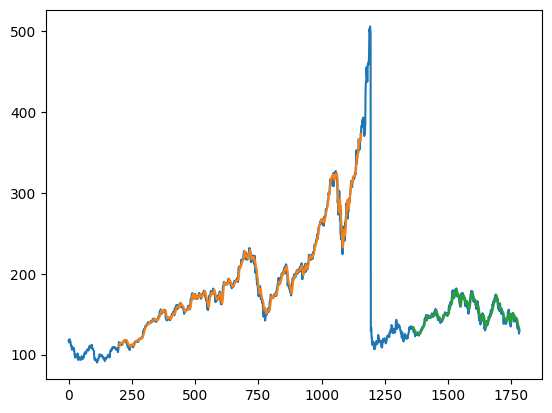

In [32]:
### Plotting
# shift train predictions for plotting
look_back=200
trainPredictPlot = numpy.empty_like(df1)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
# shift test predictions for plotting
testPredictPlot = numpy.empty_like(df1)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df1)-1, :] = test_predict
# plot baseline and predictions
plt.plot(scalar.inverse_transform(df1))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()


In [33]:
len(test_data)

625

In [34]:
x_input=test_data[525:].reshape(1,-1)  # We are using last 100 days data to predict the next day
x_input.shape

(1, 100)

In [35]:
x_input=test_data[525:].reshape(1,-1)

In [36]:
x_input.shape

(1, 100)

In [37]:
temp_input=list(x_input)
temp_input=temp_input[0].tolist()

In [39]:
#demonstrate prediction for next 30 days
from numpy import array

lst_output=[]
n_steps=100
i=0
while(i<30):
    
    if(len(temp_input)>200):
        #print(temp_input)
        x_input=np.array(temp_input[1:])
        print("{} day input {}".format(i,x_input))
        x_input=x_input.reshape(1,-1)
        x_input = x_input.reshape((1, n_steps, 1))
        #print(x_input)
        yhat = model.predict(x_input, verbose=0)
        print("{} day output {}".format(i,yhat))
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]
        #print(temp_input)
        lst_output.extend(yhat.tolist())
        i=i+1
    else:
        x_input = x_input.reshape((1, n_steps,1))
        yhat = model.predict(x_input, verbose=0)
        print(yhat[0])
        temp_input.extend(yhat[0].tolist())
        print(len(temp_input))
        lst_output.extend(yhat.tolist())
        i=i+1

[0.09769998]
101
[0.09769998]
102
[0.09769998]
103
[0.09769998]
104
[0.09769998]
105
[0.09769998]
106
[0.09769998]
107
[0.09769998]
108
[0.09769998]
109
[0.09769998]
110
[0.09769998]
111
[0.09769998]
112
[0.09769998]
113
[0.09769998]
114
[0.09769998]
115
[0.09769998]
116
[0.09769998]
117
[0.09769998]
118
[0.09769998]
119
[0.09769998]
120
[0.09769998]
121
[0.09769998]
122
[0.09769998]
123
[0.09769998]
124
[0.09769998]
125
[0.09769998]
126
[0.09769998]
127
[0.09769998]
128
[0.09769998]
129
[0.09769998]
130


In [40]:
day_new=np.arange(1,201)
day_pred=np.arange(201,231)

In [41]:
import matplotlib.pyplot as plt


In [42]:
len(df1)

1784

In [43]:
df3=df1.tolist()
df3.extend(lst_output)

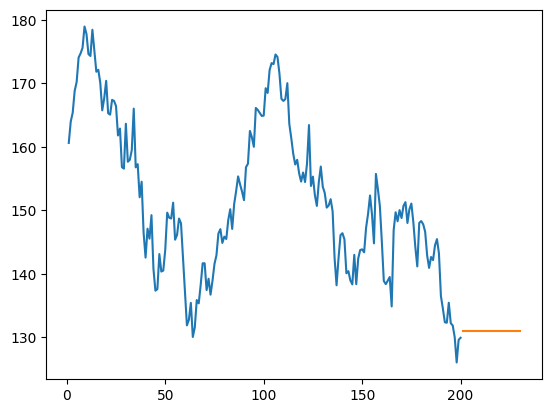

In [47]:
plt.plot(day_new,scalar.inverse_transform(df1[1584:]))
plt.plot(day_pred,scalar.inverse_transform(lst_output))

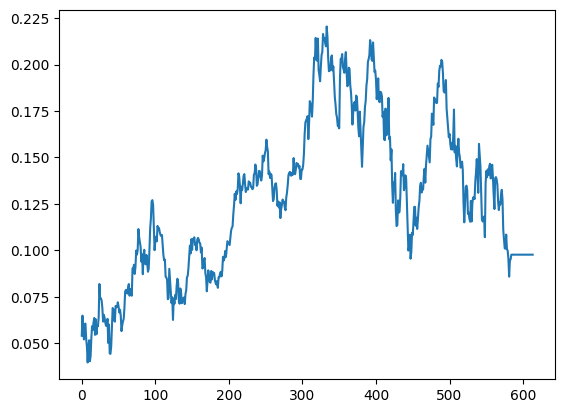

In [48]:
df3=df1.tolist()
df3.extend(lst_output)
plt.plot(df3[1200:])